# Level 2 - Task 2: Classification Analysis

## Objective

The objective of this task is to build a Classification model that predicts whether a customer is likely to churn based on customer information. The project includes data exploration, preprocessing, model training, prediction, evaluation, and visualization using Python and Scikit-learn.

# import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Customer Churn Dataset

Load the customer churn dataset into a Pandas DataFrame for classification analysis.

In [9]:
df = pd.read_csv(
    r"C:\Users\asdf\Desktop\Codeeda _Data_Analytics\Level_2\Churn Prdiction Data-20260806T063928Z-1-001\Churn Prdiction Data\churn-bigml-80.csv"
)

## Step 3: Display the First Five Rows

Display the first five rows of the dataset to understand its structure and features.

In [11]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 4: Check Dataset Information

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

## Step 5: Check Dataset Shape

In [13]:
df.shape

(2666, 20)

## Step 6: Summary Statistics

In [15]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## Step 7: Check Missing Values

In [17]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

## Step 8: Check Duplicate Rows

In [18]:
df.duplicated().sum()

np.int64(0)

## Step 9: Display Data Types

In [19]:
df.dtypes

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

## Step 10: Churn Distribution

In [20]:

df["Churn"].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

# Step 11: Visualize Churn Distribution

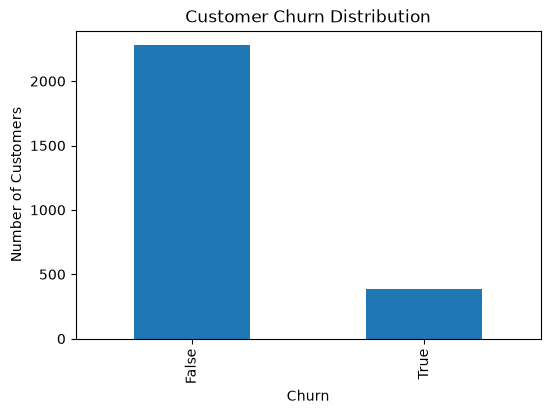

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Step 12: Count Plot

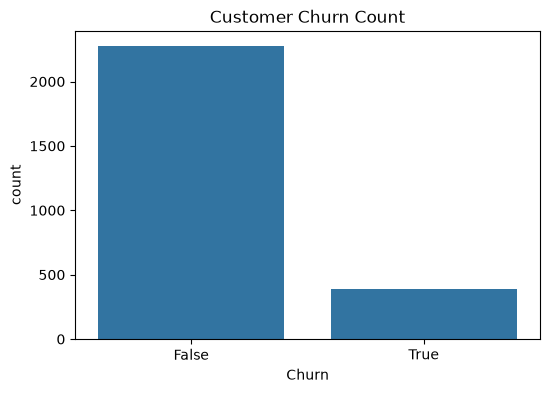

In [22]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Count")
plt.show()

# Step 13: Correlation Heatmap

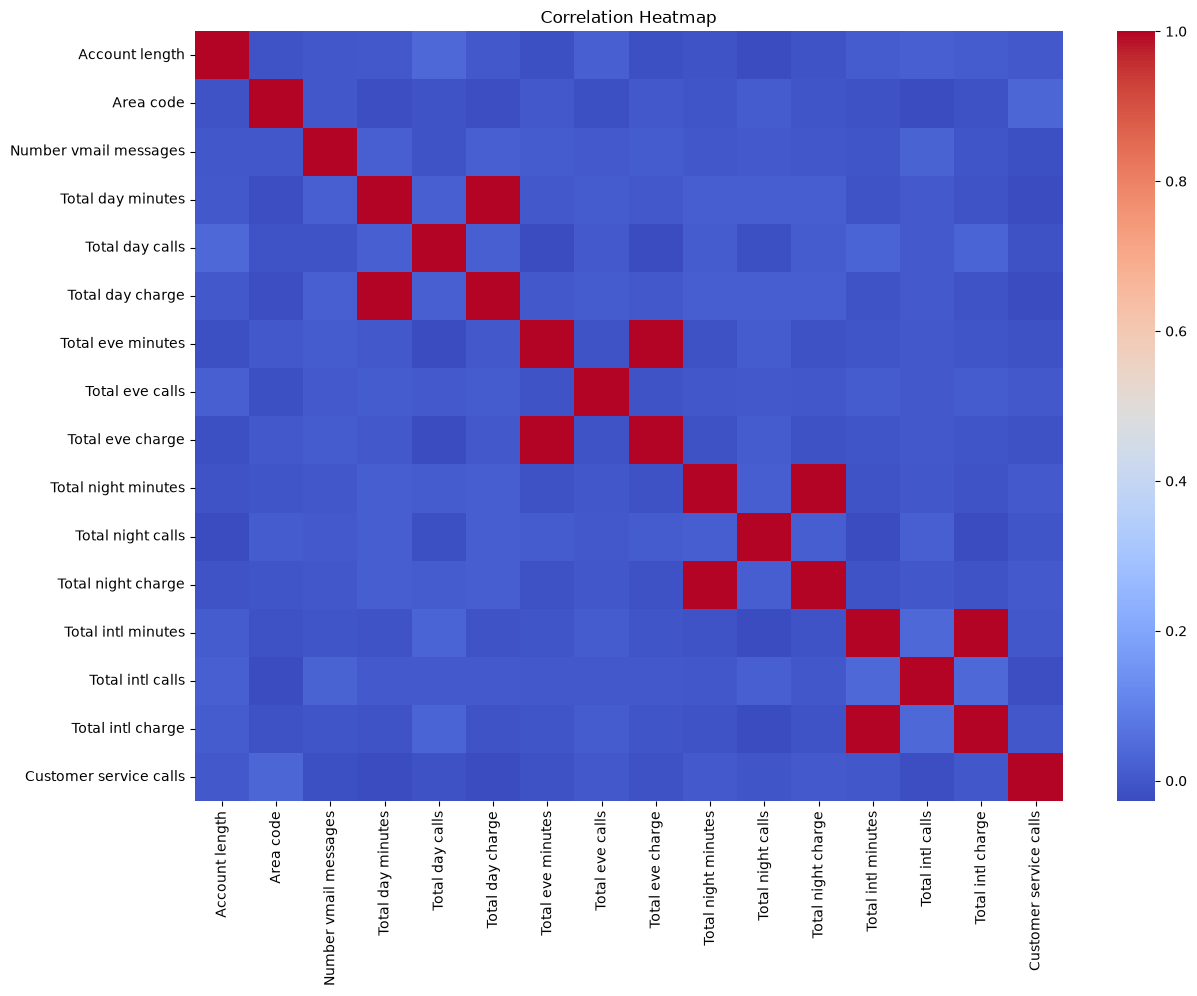

In [23]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")
plt.show()

# Step 14: Boxplot (Customer Churn vs Total Day Minutes)

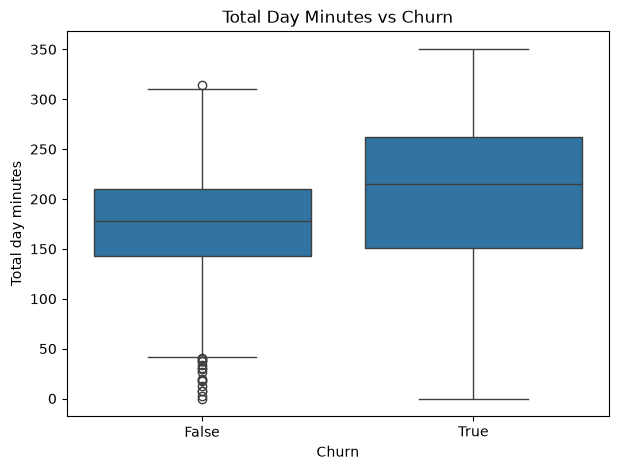

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn",
    y="Total day minutes",
    data=df
)

plt.title("Total Day Minutes vs Churn")
plt.show()

# Step 15: Boxplot (Customer Service Calls)

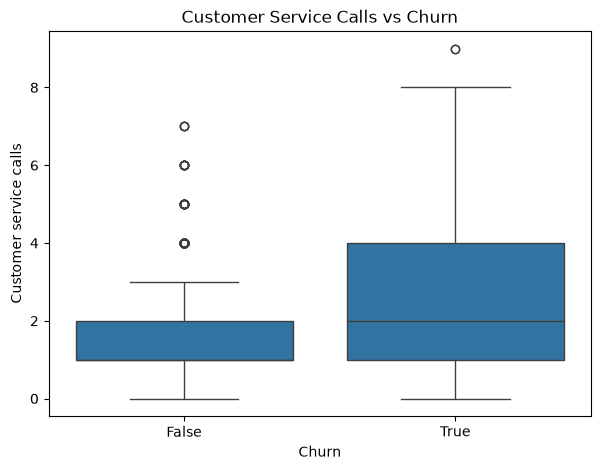

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn",
    y="Customer service calls",
    data=df
)

plt.title("Customer Service Calls vs Churn")
plt.show()

## Step 16: Convert Categorical Columns

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 17: Split Features and Target

In [28]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(2666, 19)
(2666,)


## Step 18: Split Dataset

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 19: Train Logistic Regression Model

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# step 20: Pridiction

In [35]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ True, False, False, False, False, False, False, False, False,
       False])

# Step 21: Accuracy Score

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8596


# Step 22: Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[441  14]
 [ 61  18]]


# Step 23: Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.97      0.92       455
        True       0.56      0.23      0.32        79

    accuracy                           0.86       534
   macro avg       0.72      0.60      0.62       534
weighted avg       0.83      0.86      0.83       534



# Step 24: Plot the Confusion Matrix

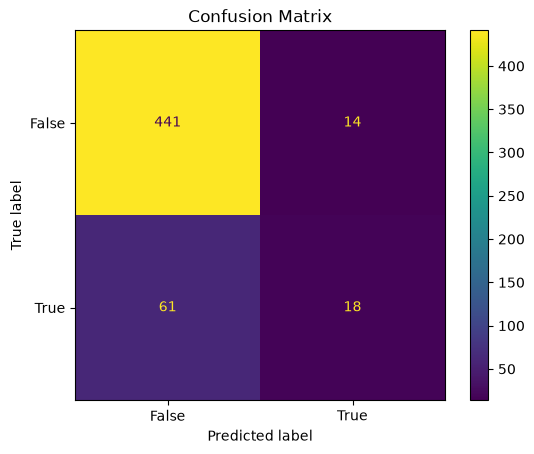

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

# Step 25: Plot the ROC Curve

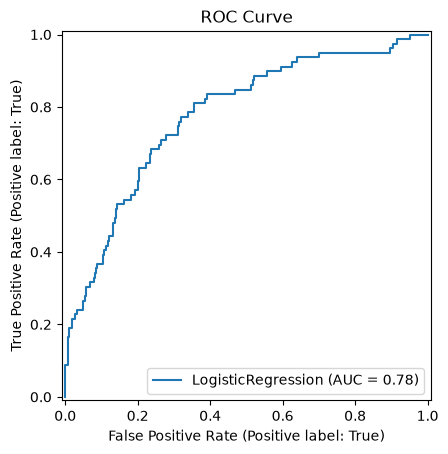

In [41]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.title("ROC Curve")
plt.show()

# Step 26: Display Feature Importance

In [42]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
3,International plan,0.667418
18,Customer service calls,0.622184
6,Total day minutes,0.371052
8,Total day charge,0.370157
5,Number vmail messages,0.328090
17,Total intl charge,0.150671
9,Total eve minutes,0.144267
11,Total eve charge,0.142849
15,Total intl minutes,0.139844
12,Total night minutes,0.076498


# Step 27: Plot Feature Importance

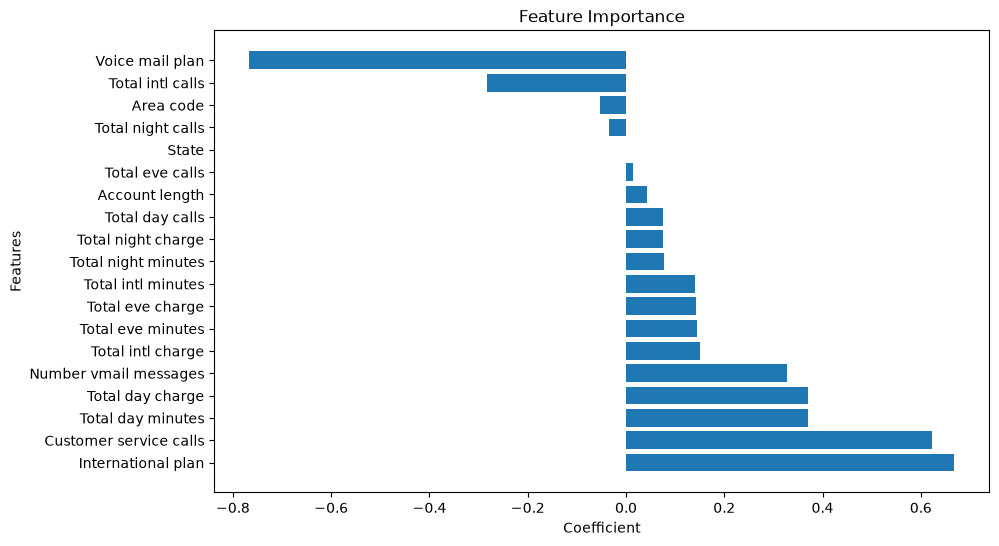

In [43]:
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Coefficient"])

plt.title("Feature Importance")

plt.xlabel("Coefficient")

plt.ylabel("Features")

plt.show()

# Step 28: Save the Trained Model

In [44]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Step 29: Save the Scaler

In [45]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


# Project Conclusion

In this project, a Customer Churn Prediction model was developed using Logistic Regression.

The dataset was explored through Exploratory Data Analysis (EDA), including summary statistics, missing value analysis, churn distribution, correlation heatmap, and boxplots.

Categorical variables were encoded, numerical features were standardized, and the dataset was split into training and testing sets.

The Logistic Regression model was trained and evaluated using Accuracy, Confusion Matrix, Classification Report, and ROC Curve.

Feature importance analysis identified the variables that most influenced customer churn. This project demonstrates the complete machine learning workflow, from data preprocessing and visualization to model development and evaluation.